## Visualisations in my thesis

In this notebook I am gathering all code used to create the visualisations in my thesis. 
The file used in this tutorial is avaliable as an Excel on my Github too. 
Some of these code snippes are found in other parts of my code in this repository too. 

### Chapter 3 Data

In [15]:
# import libraries 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pywaffle import Waffle
import poli_sci_kit
import pltviz
import seaborn as sns
from poli_sci_kit import appointment
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
import regex as re

In [3]:
# read final data set
filename = "data/processed_results.xlsx"
df = pd.read_excel(filename, index_col=0)

In [5]:
# define colours and party dictionary
party_colour_dict_name= {
    'SPÖ':'#ff0000',
    'ÖVP':'#000000',
    'FPÖ':'#0066ff',
    'Grüne':'#92d050',
    'LIF':'#ffff40',
    'BZÖ':'#ee7f00',
    'NEOS':'#e84188',
    'STRONACH':'#fecd00',
    'PILZ':'#efebdc'
}
party_colour_dict= {
    0:'#ff0000',
    1:'#000000',
    2:'#0066ff',
    3:'#92d050',
    4:'#ffff40',
    5:'#ee7f00',
    6:'#e84188',
    7:'#fecd00',
    8:'#efebdc'
}

party_dict_name= {
    0:'SPÖ',
    1:'ÖVP',
    2:'FPÖ',
    3:'Grüne',
    4:'LIF',
    5:'BZÖ',
    6:'NEOS',
    7:'STRONACH',
    8:'PILZ'
}

NA_character_    109707
SPÖ               24747
ÖVP               24063
FPÖ               17308
Grüne             12455
BZÖ                4170
LIF                1942
NEOS               1866
independent        1555
STRONACH           1322
PILZ                346
Name: party, dtype: int64


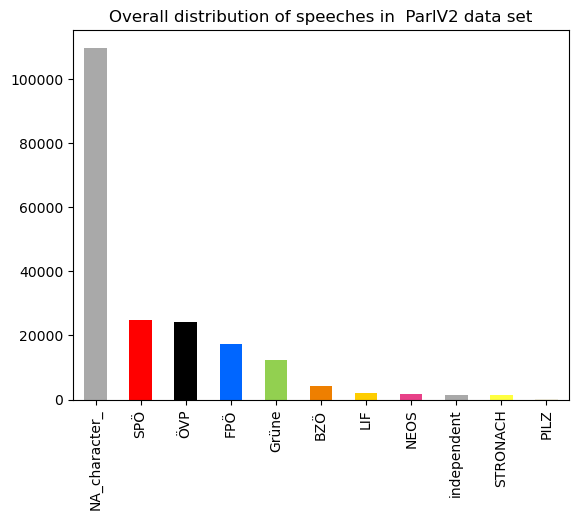

In [13]:
# Figure 3.1.

readRDS = robjects.r['readRDS']
df = readRDS('data\Corp_Nationalrat_V2.rds')
df = pandas2ri.rpy2py_dataframe(df)
df['party']= df['party'].replace(to_replace='Jetzt – Liste PILZ', value='PILZ', regex=True)
df['party']= df['party'].replace(to_replace='JETZT', value='PILZ', regex=True)

all_party_colours= ['#a9a9a9','#ff0000','#000000','#0066ff','#92d050','#ee7f00','#fecd00','#e84188','#a9a9a9','#ffff40','#efebdc']
df['party'].value_counts().plot(kind='bar',color=all_party_colours)
plt.title('Overall distribution of speeches in  ParlV2 data set')
print(df['party'].value_counts())
plt.show()

SPÖ            24747
ÖVP            24063
FPÖ            17308
Grüne          12455
BZÖ             4170
LIF             1942
NEOS            1866
independent     1555
STRONACH        1322
PILZ             346
Name: party, dtype: int64


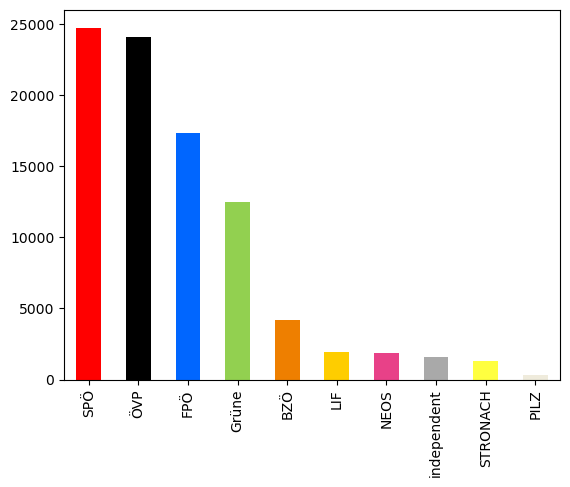

In [16]:
# Figure 3.2.
readRDS = robjects.r['readRDS']
df = readRDS('data\Corp_Nationalrat_V2.rds')
df = pandas2ri.rpy2py_dataframe(df)
df['party']= df['party'].replace(to_replace='Jetzt – Liste PILZ', value='PILZ', regex=True)
df['party']= df['party'].replace(to_replace='JETZT', value='PILZ', regex=True)

all_party_colours= ['#a9a9a9','#ff0000','#000000','#0066ff','#92d050','#ee7f00','#fecd00','#e84188','#a9a9a9','#ffff40','#efebdc']
df['party'].value_counts().plot(kind='bar',color=all_party_colours)
plt.title('Overall distribution of speeches in  ParlV2 data set')
print(df['party'].value_counts())
plt.show()

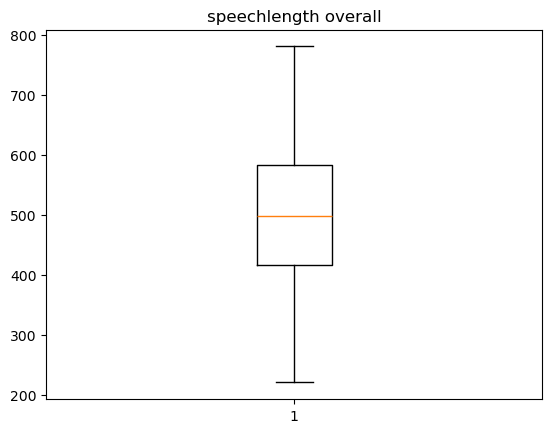

In [17]:
# Figure 3.3.
#filter out speeches by president of parliament and scribes
search = "präsident"
df['count_president']= df["speaker"].str.count(search, re.I)

search_2 = "bundesminister"
df['count_minister']= df["speaker"].str.count(search_2, re.I)


search_3 = "schriftführer"
df['count_scribe'] = df["speaker"].str.count(search_3, re.I)


df = df[df['count_president']<1]
df = df[df['count_scribe']<1]

all_party_colours= ['#ff0000','#000000','#0066ff','#92d050','#ee7f00','#fecd00','#e84188','#a9a9a9','#ffff40','#efebdc']
df['party'].value_counts().plot(kind='bar',color=all_party_colors)
print(df['party'].value_counts())
plt.show()


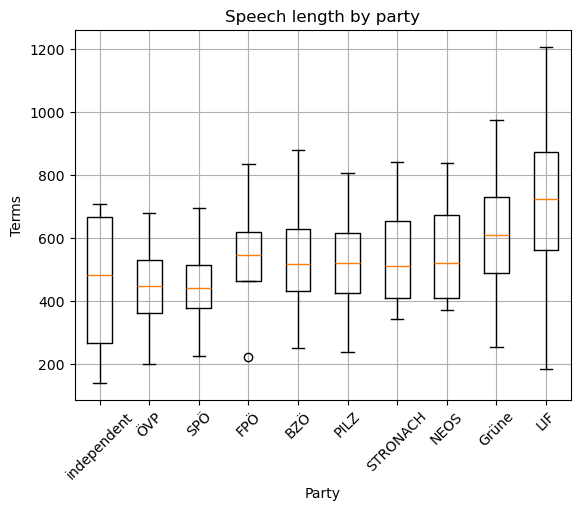

In [18]:
# Figure 3.4.

data= [df['terms'].std(),df['terms'].median(),df['terms'].quantile(0.75),df['terms'].quantile(0.25)]
fig1, ax1 = plt.subplots()
ax1.set_title('speechlength overall')
ax1.boxplot(data)
plt.show()

In [27]:
# Figure 3.5.
# Figure 3.4.

groups = df.groupby('party')['terms']

# sort by median (change this if you want a different metric)
groups_sorted = sorted(groups, key=lambda x: np.median(x[1].values))

data = [[
    group.values.std(),
    np.median(group.values),
    np.quantile(group.values, 0.75),
    np.quantile(group.values, 0.25)
] for name, group in groups_sorted]

labels = [name for name, group in groups_sorted]

fig, ax = plt.subplots()
ax.set_title('Speech length by party')
ax.boxplot(data, tick_labels=labels)

ax.set_xlabel('Party')
ax.set_ylabel('Terms')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [28]:
# Figure 3.6.

In [29]:
# Figure 3.7.

In [30]:
# Figure 3.8.

In [31]:
# Figure 3.9

In [32]:
# Figure 3.10 to 3.16

In [33]:
# Figure 3.17

### Chapter 4 Data preprocessing and training

In [34]:
# Figure 4.1

### Chapter 5 Evaluation and Results

In [35]:
# Figure 5.1

### Chapter 6 Political Developements

In [36]:
# Figure 6.1 and 6.2

In [37]:
# Figure 6.3

In [38]:
# Figure 6.4 and 6.5

In [39]:
# Figure 6.6 to 6.10

In [40]:
# Figure 6.11 to 6.22

In [41]:
# Figure 6.23 to 6.27